# The Range Estimators \U0001F4CF
### The high and the low know more than the close — until the market gaps

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

Every volatility textbook says the same thing: stop throwing away the day's high and low,
because the range measures volatility about five times better than the closing price does.
It is a theorem, it is correct, and the market it was proved in never closes for the night.
This notebook checks the claim where the answer is known, then finds the hole.

> \U0001F4D3 **This is the plain-language layer.** The estimator algebra, the QLIKE race and
> the Diebold-Mariano tests are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is the five-times efficiency claim true? | **Yes** — in a simulated market that never closes, which is where it was proved. |
| Does it survive on a real market? | Only in part. Parkinson, Garman-Klass and Rogers-Satchell cannot see the overnight gap, and for an equity ETF that gap is a large slice of the day's variance. |
| So which estimator should you use? | **Yang-Zhang**, the only one built to contain the gap — or a rescaled range estimator if you know what you are correcting for. |
| Is the gain worth chasing? | It is real and it is modest. Nobody's P&L was ever saved by a better variance estimator; a few risk limits were. |

## 1 · The claim

> *"Squared close-to-close returns waste the whole day. You watched the price travel from
> the low to the high and back and then you recorded one number. Use the range: Parkinson
> (1980) proved it is five times as efficient, so you get five years of information out of
> one."*

That is not marketing — it is a theorem, and the theorem is right. The interesting part is
its footnote: it assumes the price follows a continuous random walk **all the time**, with no
overnight jump.

## 2 · So what?

Volatility is the input to nearly everything downstream: position sizing, risk limits, option
pricing, stop distances. An estimator that is five times more efficient means your risk
system reacts to a real change in five days instead of twenty-five. And an estimator that
quietly reports 60% of the truth means your risk limits are wrong by 40%.

## 3 · How would we even know?

Efficiency is a statement about how close an estimate is to the truth — so we need a world
where the truth exists. That world is a simulation: we generate bars from a known daily
sigma, with a controllable overnight gap, and score every estimator against it.

In [2]:
from range_vol import data, strategy as st

bars = data.load_all()
spy = bars["SPY"]
print(f"as-of {data.AS_OF} | SPY {spy.index[0].date()} -> {spy.index[-1].date()} "
      f"({len(spy):,} bars, {data.bad_bar_count('SPY')} dropped as broken)")
print(f"overnight share of SPY's daily variance: {st.overnight_share(spy):.0%}")

as-of 2026-06-30 | SPY 1993-01-29 -> 2026-06-30 (8,411 bars, 0 dropped as broken)
overnight share of SPY's daily variance: 33%


## 4 · The teardown

### 4.1 The claim, in the world where it was proved

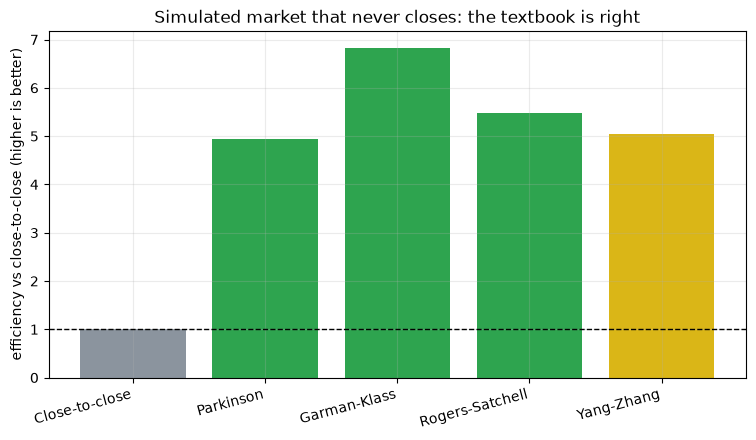

,mse,efficiency_vs_cc,mean_ratio_to_truth,n,windowed
estimator,,,,,
close_close,0.0000,1.0000,1.0090,10079,False
parkinson,0.0000,4.9330,0.8590,10080,False
garman_klass,0.0000,6.8330,0.8010,10080,False
rogers_satchell,0.0000,5.4770,0.7980,10080,False
yang_zhang,0.0000,5.0340,1.2490,10059,True


In [3]:
sim, tr = data.synthetic_ohlc(n_years=40, overnight_share=0.0, seed=965)
eff = st.efficiency_table(sim, tr["sigma"])
fig, ax = plt.subplots(figsize=(9, 4.5))
lbl = [st.ESTIMATOR_LABEL[c].split(" (")[0] for c in eff.index]
ax.bar(lbl, eff["efficiency_vs_cc"], color=["#8b949e", "#2ea44f", "#2ea44f", "#2ea44f", "#dab617"])
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("efficiency vs close-to-close (higher is better)")
ax.set_title("Simulated market that never closes: the textbook is right")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
eff.round(3)

### 4.2 Now let the market close for the night

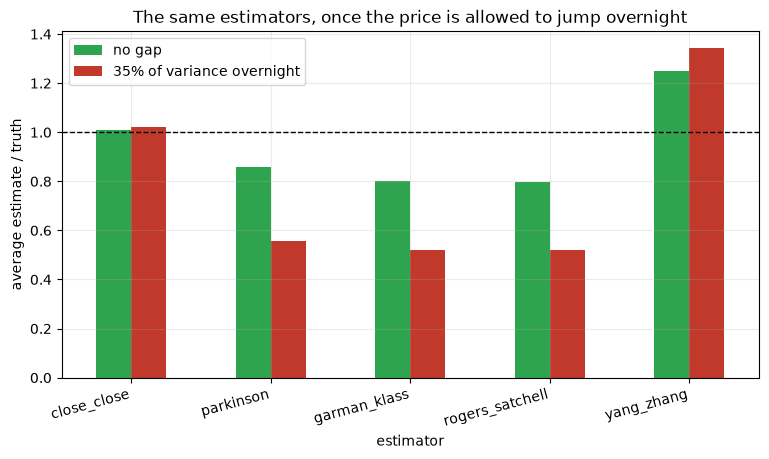

,no gap,35% of variance overnight
estimator,,
close_close,1.0090,1.0230
parkinson,0.8590,0.5580
garman_klass,0.8010,0.5210
rogers_satchell,0.7980,0.5190
yang_zhang,1.2490,1.3450


In [4]:
sim2, tr2 = data.synthetic_ohlc(n_years=40, overnight_share=0.35, seed=965)
eff2 = st.efficiency_table(sim2, tr2["sigma"])
comp = pd.DataFrame({"no gap": eff["mean_ratio_to_truth"],
                     "35% of variance overnight": eff2["mean_ratio_to_truth"]})
fig, ax = plt.subplots(figsize=(9, 4.5))
comp.plot.bar(ax=ax, color=["#2ea44f", "#c0392b"])
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("average estimate / truth")
ax.set_title("The same estimators, once the price is allowed to jump overnight")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(title="")
plt.show()
comp.round(3)

> \U0001F52C **For the quants.** Notice what is *not* happening: the range estimators do not
> become noisy. They stay precise — precisely wrong. A biased-but-tight estimator is more
> dangerous than a noisy unbiased one, because it never looks unreliable.

### 4.3 The real tape agrees

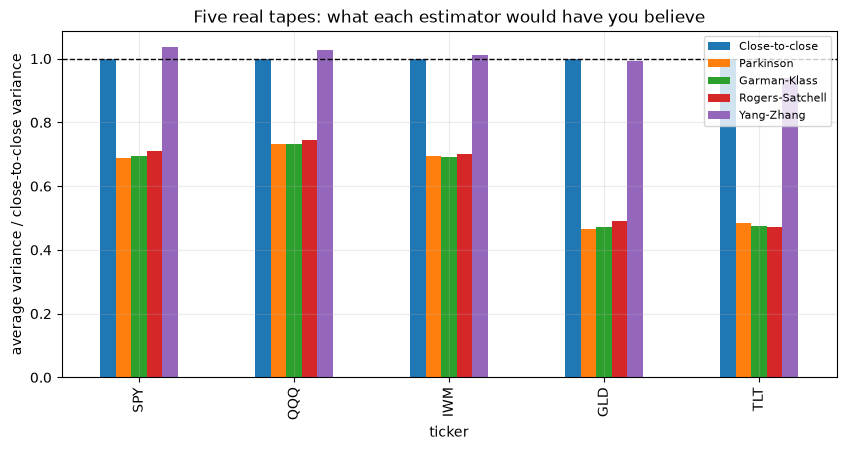

,overnight share,Close-to-close,Parkinson,Garman-Klass,Rogers-Satchell,Yang-Zhang
ticker,,,,,,
SPY,0.3300,1.0000,0.6900,0.7000,0.7100,1.0400
QQQ,0.2800,1.0000,0.7300,0.7300,0.7400,1.0300
IWM,0.3100,1.0000,0.7000,0.6900,0.7000,1.0100
GLD,0.5100,1.0000,0.4700,0.4700,0.4900,0.9900
TLT,0.4700,1.0000,0.4800,0.4700,0.4700,0.9400


In [5]:
rows = []
for tk, b in bars.items():
    t = st.bias_table(b)
    rows.append({"ticker": tk, "overnight share": st.overnight_share(b),
                 **{st.ESTIMATOR_LABEL[c].split(" (")[0]: t.loc[c, "ratio_to_cc"]
                    for c in st.ESTIMATORS}})
tbl = pd.DataFrame(rows).set_index("ticker")
fig, ax = plt.subplots(figsize=(10, 4.5))
tbl.drop(columns=["overnight share"]).plot.bar(ax=ax)
ax.axhline(1.0, color="k", lw=1, ls="--")
ax.set_ylabel("average variance / close-to-close variance")
ax.set_title("Five real tapes: what each estimator would have you believe")
ax.legend(title="", fontsize=8)
plt.show()
tbl.round(2)

Gold and Treasuries are the interesting cases: GLD's underlying trades around the clock, so a
large share of its "daily" variance lands outside the US session and the gap-blind estimators
miss even more of it.

## 5 · The verdict

**Signal: Real.** On simulated bars where the day's true sigma is known, Parkinson's estimator has **4.9x** the efficiency of close-to-close against the truth (Garman-Klass 6.8x, Rogers-Satchell 5.5x) — the textbook claim survives, in the textbook's own world. On the real tape that world does not exist: the overnight gap carries **33%** of SPY's daily variance and none of the three can see it, so they report **69%** of the close-to-close level.

**Usefulness: Useful.** Rescaled to remove that level error, the best range estimator (Yang-Zhang (2000)) beat close-to-close on QLIKE on **5 of 5** tapes with a pooled Diebold-Mariano *t* of **+3.73** — a real but modest improvement in forecasting the next month's realised variance (22.4% lower QLIKE on SPY). Yang-Zhang, the only gap-aware estimator, needs no rescaling and is the honest default.

## 6 · Could you actually use it?

Fix the level error — multiply each estimator by a scale factor learned on the first two
years only — and ask the practical question: does the extra information in the bar predict
next month's realised variance better?

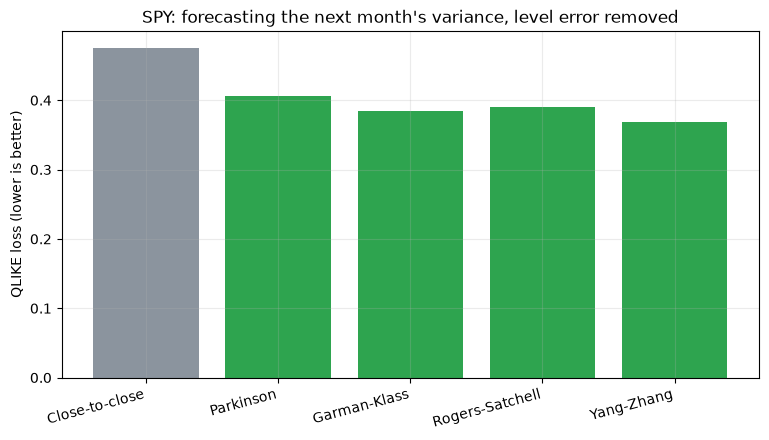

,scale,qlike,mse,n,dm_vs_cc,p_vs_cc
estimator,,,,,,
close_close,1.0000,0.4759,0.0000,7885,NaN,NaN
parkinson,1.5296,0.4068,0.0000,7885,2.8404,0.0045
garman_klass,1.6851,0.3845,0.0000,7885,3.7352,0.0002
rogers_satchell,1.6668,0.3897,0.0000,7885,3.3843,0.0007
yang_zhang,1.1460,0.3693,0.0000,7885,5.3455,0.0000


In [6]:
t = st.scaled_forecast_race(spy, burn=504)
fig, ax = plt.subplots(figsize=(9, 4.5))
lbl = [st.ESTIMATOR_LABEL[c].split(" (")[0] for c in t.index]
colors = ["#8b949e" if c == "close_close" else "#2ea44f" for c in t.index]
ax.bar(lbl, t["qlike"], color=colors)
ax.set_ylabel("QLIKE loss (lower is better)")
ax.set_title("SPY: forecasting the next month's variance, level error removed")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
t.round(4)

## 7 · Going further \U0001F6AA

- **Intraday data** turns this from a forecast comparison into a real efficiency measurement:
  with 5-minute bars there is a realised-variance benchmark and the whole simulation section
  becomes unnecessary.
- **The high and low you can trade.** Consolidated-tape extremes include prints nobody could
  have hit; a study on NBBO-filtered extremes would shrink every range estimator slightly.
- **Position sizing.** The interesting downstream question is whether a better variance
  estimate improves a vol-targeted portfolio — a different study, and a harder one.